In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("All libraries loaded")

All libraries loaded


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

xl = pd.ExcelFile('../data/raw/Apparel_Store_Inventory_JIT_Dataset.xlsx')

sales = pd.read_excel(xl, 'Daily_Sales_Transactions', header=3)
products = pd.read_excel(xl, 'Product_Master', header=3)
inventory = pd.read_excel(xl, 'Inventory_Snapshot', header=3)
velocity = pd.read_excel(xl, 'SKU_Velocity_Summary', header=3)

print("Sales shape:", sales.shape)
print("Products shape:", products.shape)
print("Inventory shape:", inventory.shape)
print("Velocity shape:", velocity.shape)
print()
print("All data loaded successfully")

Sales shape: (45423, 11)
Products shape: (576, 19)
Inventory shape: (576, 7)
Velocity shape: (576, 18)

All data loaded successfully


In [4]:
# Fix date and sort
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values(['SKU', 'Date']).reset_index(drop=True)

# Filter to one SKU
sku = sales[sales['SKU'] == 'AP-1001'].copy()
sku = sku.reset_index(drop=True)

print("Rows for AP-1001:", len(sku))
print(sku.head())

Rows for AP-1001: 84
        Date      SKU                                  Store  Units Sold  \
0 2026-01-02  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
1 2026-01-03  AP-1001  Urban Threads - Bengaluru Mall Outlet           2   
2 2026-01-08  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
3 2026-01-12  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   
4 2026-01-14  AP-1001  Urban Threads - Bengaluru Mall Outlet           1   

   MRP (INR)  Discount %  Selling Price (INR)  Revenue (INR)  \
0        670           0                  670            670   
1        670           0                  670           1340   
2        670           0                  670            670   
3        670           0                  670            670   
4        670           0                  670            670   

   Stock On Hand (Start of Day) Stockout Flag Day of Week  
0                            83            No      Friday  
1                

In [5]:
# Build features
sku['is_weekend'] = sku['Day of Week'].isin(['Saturday','Sunday']).astype(int)
sku['is_discount'] = (sku['Discount %'] > 0).astype(int)
sku['lag_1'] = sku['Units Sold'].shift(1).fillna(0)
sku['day_num'] = range(len(sku))

# Define X and y
X = sku[['day_num','is_weekend','is_discount','lag_1',
         'Stock On Hand (Start of Day)']].values
y = sku['Units Sold'].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("First 3 rows of X:")
print(X[:3])
print()
print("First 3 values of y:", y[:3])

X shape: (84, 5)
y shape: (84,)

First 3 rows of X:
[[ 0.  0.  0.  0. 83.]
 [ 1.  1.  0.  1. 82.]
 [ 2.  0.  0.  2. 80.]]

First 3 values of y: [1 2 1]


In [6]:
# Split 80% train, 20% test — time order preserved
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training matches:", len(X_train))
print("Test matches:", len(X_test))
print("Training period ends at row:", split)

Training matches: 67
Test matches: 17
Training period ends at row: 67


In [7]:
# Normalise using training data only
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

print("Feature means:", X_mean.round(2))
print("Feature stds:", X_std.round(2))
print("Normalised X_train first row:", X_train_norm[0].round(3))

Feature means: [33.    0.33  0.12  1.34 47.73]
Feature stds: [19.34  0.47  0.32  0.59 21.55]
Normalised X_train first row: [-1.706 -0.699 -0.368 -2.287  1.636]


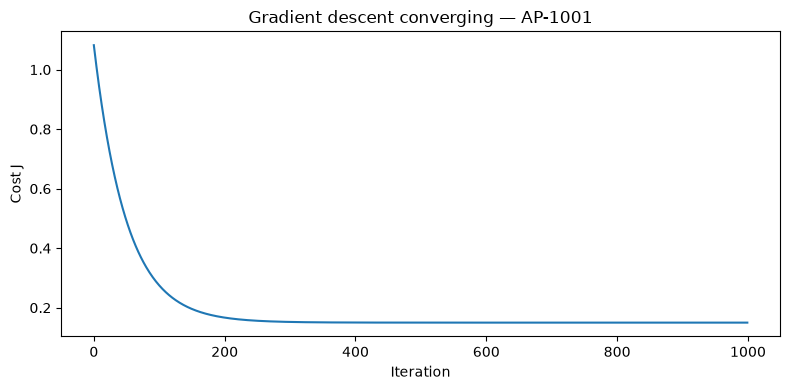

Learned weights:
  day_num             : 0.0086
  is_weekend          : 0.1309
  is_discount         : -0.0495
  lag_1               : -0.0150
  stock_on_hand       : 0.0193
  bias                : 1.3582


In [9]:
# Initialise weights
w = np.zeros(5)
b = 0.0
alpha = 0.01
iterations = 1000
m = len(X_train_norm)
cost_history = []

# Gradient descent loop
for i in range(iterations):
    predictions = X_train_norm @ w + b
    errors = predictions - y_train
    
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)
    
    dw = (1/m) * X_train_norm.T @ errors
    db = (1/m) * np.sum(errors)
    
    w = w - alpha * dw
    b = b - alpha * db

# Plot cost falling
plt.figure(figsize=(8,4))
plt.plot(cost_history)
plt.title('Gradient descent converging — AP-1001')
plt.xlabel('Iteration')
plt.ylabel('Cost J')
plt.tight_layout()
plt.show()

print("Learned weights:")
features = ['day_num','is_weekend','is_discount','lag_1','stock_on_hand']
for feat, weight in zip(features, w):
    print(f"  {feat:20s}: {weight:.4f}")
print(f"  {'bias':20s}: {b:.4f}")

In [10]:
# Evaluate on test set
test_predictions = X_test_norm @ w + b

errors = test_predictions - y_test
MAE = np.mean(np.abs(errors))
RMSE = np.sqrt(np.mean(errors**2))

print("=== Model Performance on Test Set ===")
print(f"MAE:  {MAE:.4f} units")
print(f"RMSE: {RMSE:.4f} units")
print()
print(f"Average actual sales in test period: {y_test.mean():.4f}")
print(f"Model is wrong by {MAE:.2f} units on average")

=== Model Performance on Test Set ===
MAE:  0.3678 units
RMSE: 0.4395 units

Average actual sales in test period: 1.1765
Model is wrong by 0.37 units on average


In [11]:
# Evaluate on test set
test_predictions = X_test_norm @ w + b

errors = test_predictions - y_test
MAE = np.mean(np.abs(errors))
RMSE = np.sqrt(np.mean(errors**2))

print("=== Model Performance on Test Set ===")
print(f"MAE:  {MAE:.4f} units")
print(f"RMSE: {RMSE:.4f} units")
print()
print(f"Average actual sales in test period: {y_test.mean():.4f}")
print(f"Model is wrong by {MAE:.2f} units on average")

=== Model Performance on Test Set ===
MAE:  0.3678 units
RMSE: 0.4395 units

Average actual sales in test period: 1.1765
Model is wrong by 0.37 units on average


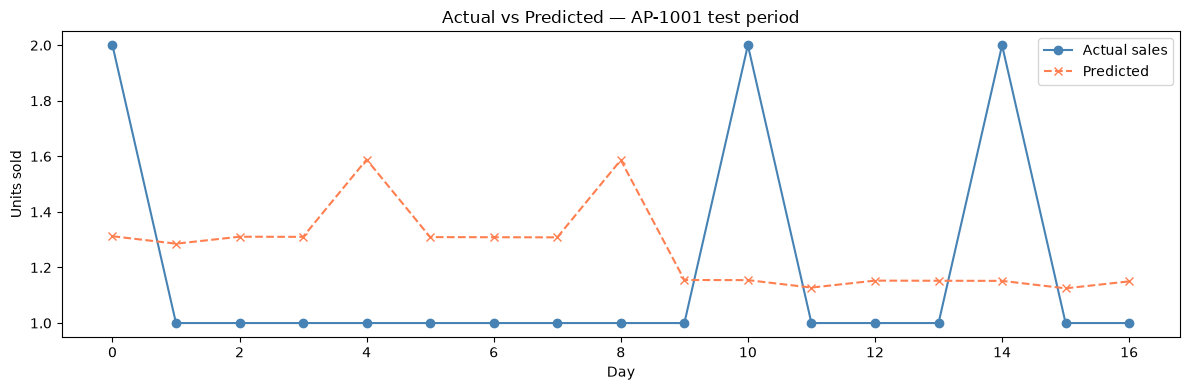

In [12]:
plt.figure(figsize=(12,4))
plt.plot(y_test, label='Actual sales', 
         color='steelblue', marker='o')
plt.plot(test_predictions, label='Predicted', 
         color='coral', linestyle='--', marker='x')
plt.title('Actual vs Predicted — AP-1001 test period')
plt.xlabel('Day')
plt.ylabel('Units sold')
plt.legend()
plt.tight_layout()
plt.show()

## Baseline Model Results — AP-1001
- MAE: 0.37 units, RMSE: 0.44 units
- Model predicts near-average for every day
- Fails to capture demand spikes (days 0, 10, 14)
- Root cause: AP-1001 too sparse (84 days) for 
  individual SKU regression
- Decision: move to category-level modelling for 
  sparse SKUs, confirmed EDA finding 4
- Next step: build sklearn model on aggregated 
  category data and compare MAE